In [ ]:
%pip install plotly ipywidgets anywidget kaleido h5py pillow

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# Setup — load tutorial data and pick a render mode.
#
#   INTERACTIVE = False  →  static plots (Plotly-PNG + matplotlib) that render
#                           on GitHub. Good for sharing this notebook online.
#   INTERACTIVE = True   →  live ipywidgets viewers — clickable S2 sphere, PrD
#                           slider, ψ slider, etc. Use when running locally on
#                           your own data.
# ─────────────────────────────────────────────────────────────────────────────
from visualization import load_session

INTERACTIVE = False

viz = load_session()

Auto-detected TOML: params_20260101_RyR_tutorial.toml
Using TOML file: /Users/rdsouza/Dev/Manifold_From_GA2/ManifoldEM/tutorial/RyR1GCs_demo/params_20260101_RyR_tutorial.toml
project_name: 20260101_RyR_tutorial
Loading: /Users/rdsouza/Dev/Manifold_From_GA2/ManifoldEM/tutorial/RyR1GCs_demo/output/20260101_RyR_tutorial/pd_data.pkl

Loaded keys: ['thres_low', 'thres_high', 'bin_centers', 'defocus', 'microscope_origin', 'pos_raw']…
  bin_centers       : (3, 2005)
  occupancy_full    : (2005,)
  pos_thresholded   : (3, 53)
  thres_low / high  : 100 / 2000


### Plot the S2 tesselation results

### S2 orientation distribution

Points are the **tessellation bin centres** on the unit sphere S2.  
Colour = particle occupancy per bin (number of cryo-EM images whose orientation maps to that bin).  
**Thresholded PDs** (active projection directions after low/high occupancy cuts) are overlaid as larger red markers.

> With `INTERACTIVE=True` the sphere is a clickable Plotly figure (click a red diamond to view its 2D class average and sync the PrD slider below). With `INTERACTIVE=False` you get a static PNG snapshot suitable for GitHub.

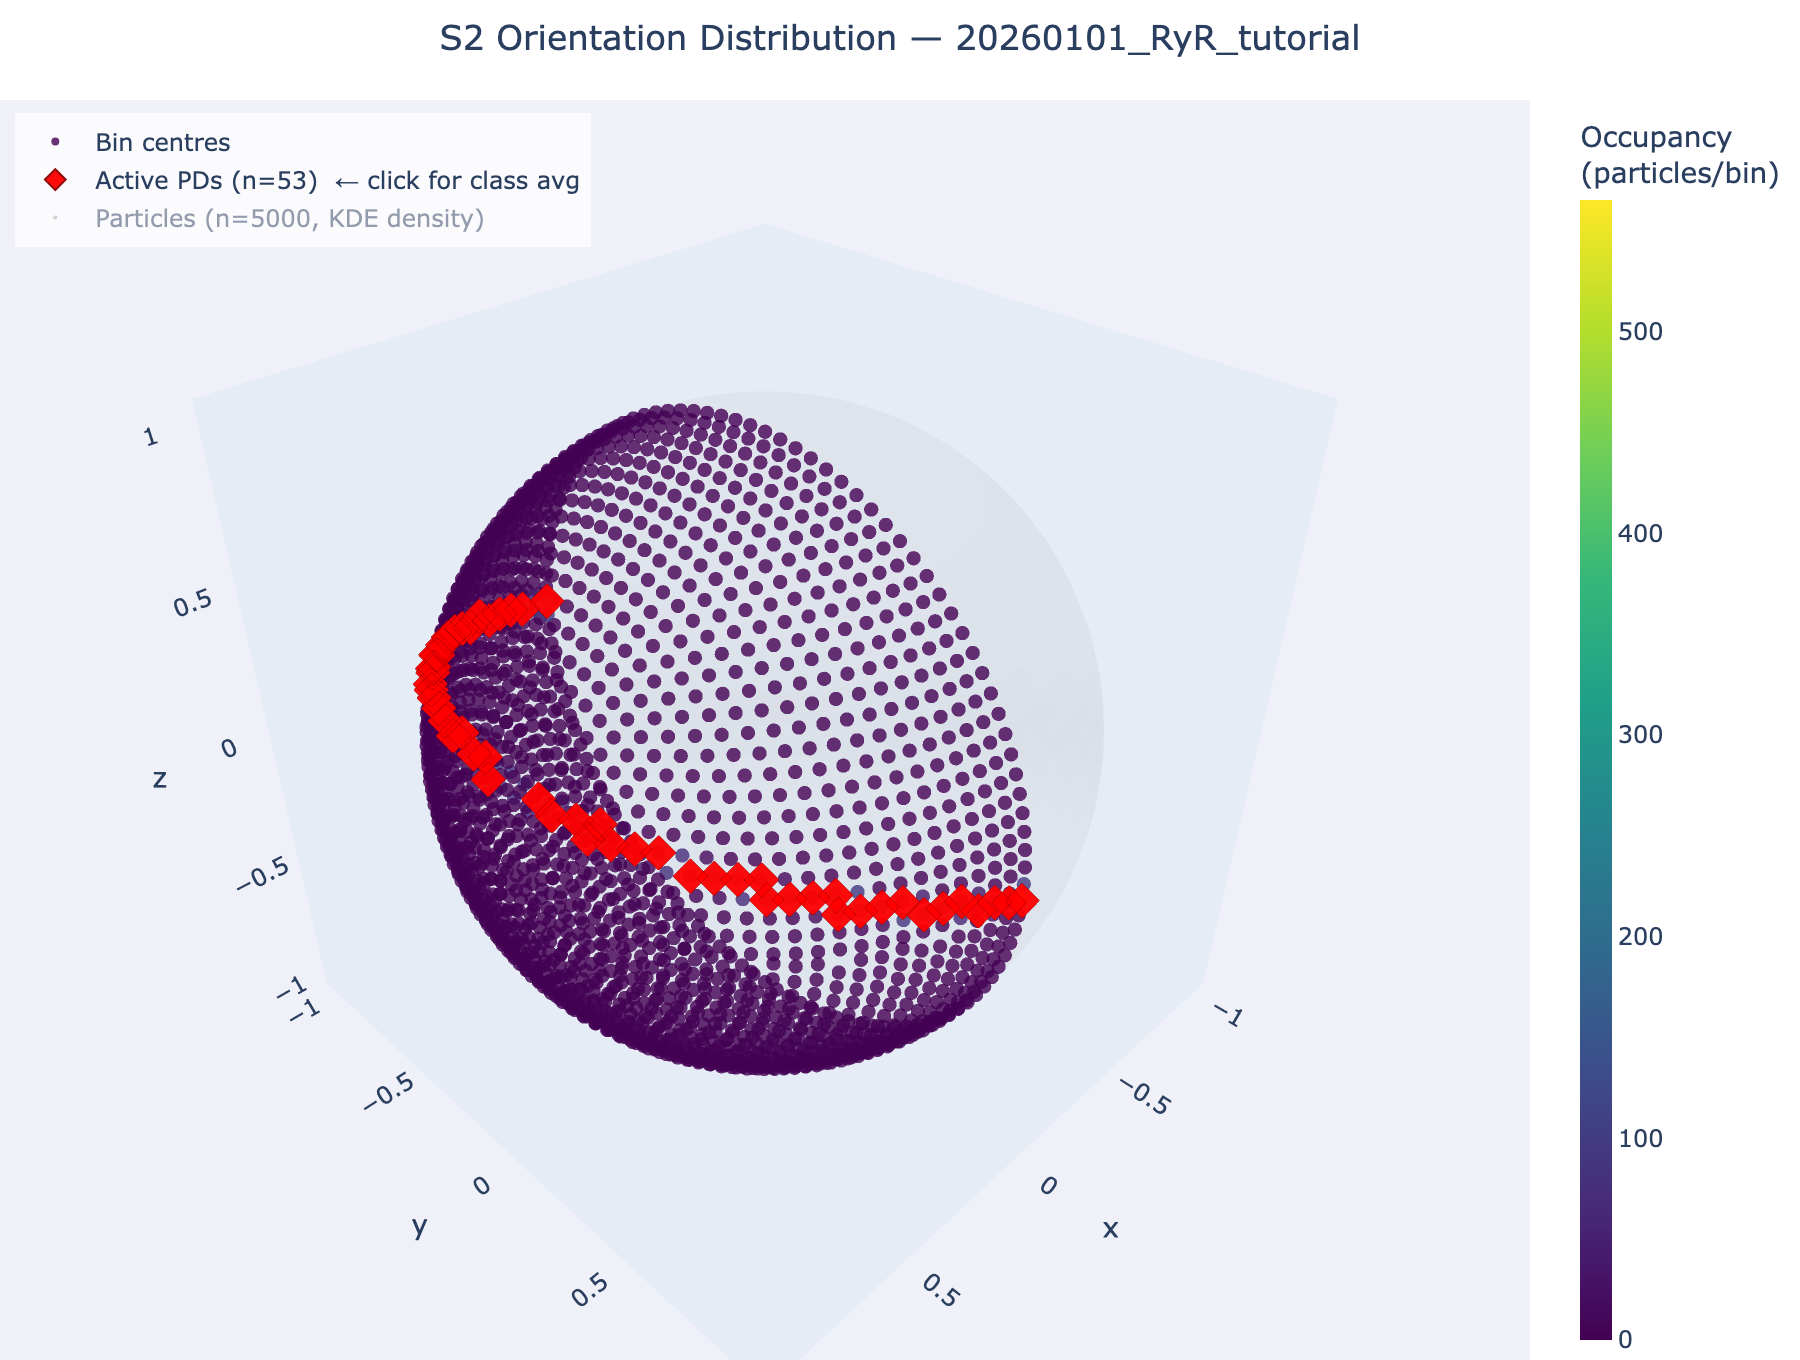

Active PDs: 53  |  Total bins: 2005  |  Total particles: 14491  [static view — set INTERACTIVE=True for clickable diamonds]


In [11]:
viz.show_s2_sphere(interactive=INTERACTIVE)

### Per-PrD eigenvector viewer

**Tab 1** shows the eigenvalue scree plot. **Tab 2** shows the eigenvector movies (`psi_1` … `psi_8`).

> With `INTERACTIVE=True`, select a PrD with the slider (or click a diamond on the sphere above). With `INTERACTIVE=False`, the viewer renders PrD 1 (override with `viz.show_prd_viewer(default_prd=N, interactive=INTERACTIVE)`) and the movies are shown as first-frame thumbnails.

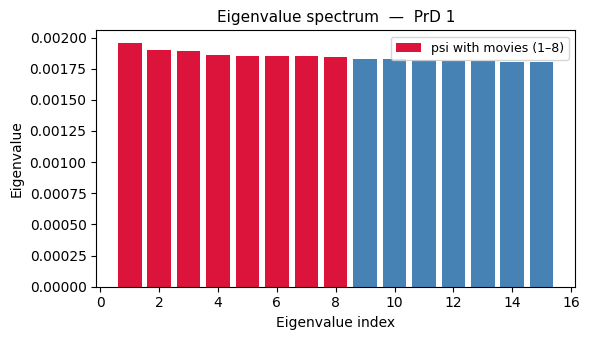

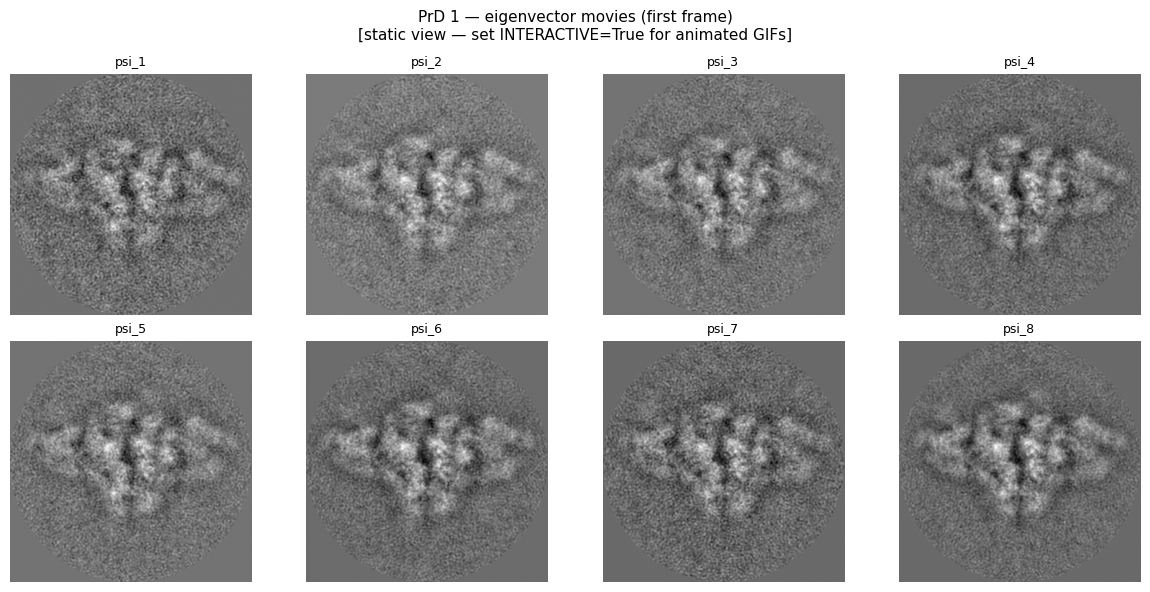

In [12]:
viz.show_prd_viewer(interactive=INTERACTIVE)

### Diffusion map analysis (per PrD)

**Row 1 — Left:** pairwise image distance matrix `D`, rows/columns reordered by `posPath` (the diffusion-derived conformational ordering). A well-behaved manifold shows a band-diagonal structure.  
**Row 1 — Right:** Ferguson plot — `ln Σ Wᵢⱼ` vs `ln ε` scatter with tanh fit. The inflection gives the optimal kernel width σ; the slope at the inflection estimates the intrinsic dimensionality.  
**Row 2:** ψ₁ vs ψ₂ diffusion map embedding coloured three ways: conformational order (`posPath`), Riemannian density (`μ`), and in-plane rotation angle.

> With `INTERACTIVE=True`, this panel is driven by the PrD slider above. With `INTERACTIVE=False` it renders PrD 1 (override via `viz.show_diffusion_map(default_prd=N, interactive=INTERACTIVE)`).

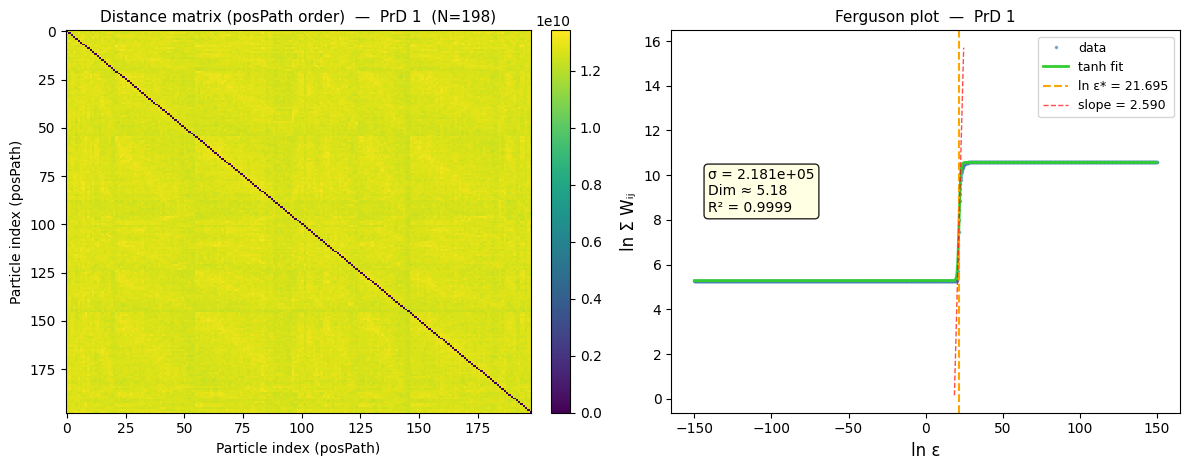

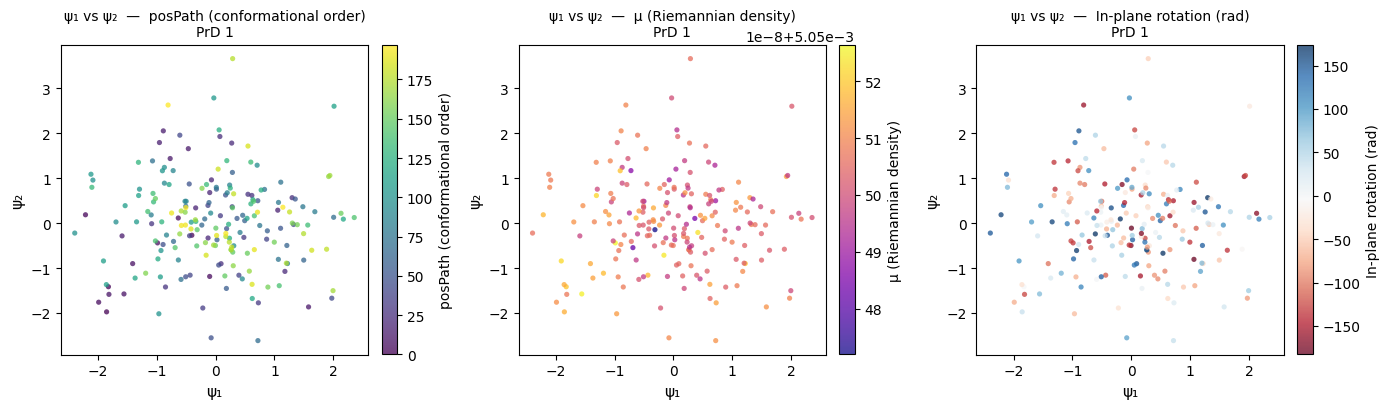

[static view — showing PrD 1. Set INTERACTIVE=True to drive this with the PrD slider.]


In [13]:
viz.show_diffusion_map(interactive=INTERACTIVE)

### CC voting — chosen ψ and FWD/REV sense per PrD

The compilation step votes on (i) which eigenvector ψ_k best captures conformational motion at each PrD and (ii) whether that motion runs in the same (`+1` FWD) or opposite (`−1` REV) sense as a reference PrD.

> With `INTERACTIVE=True`, this cell also recolours the red diamonds on the S2 sphere above by their chosen ψ.

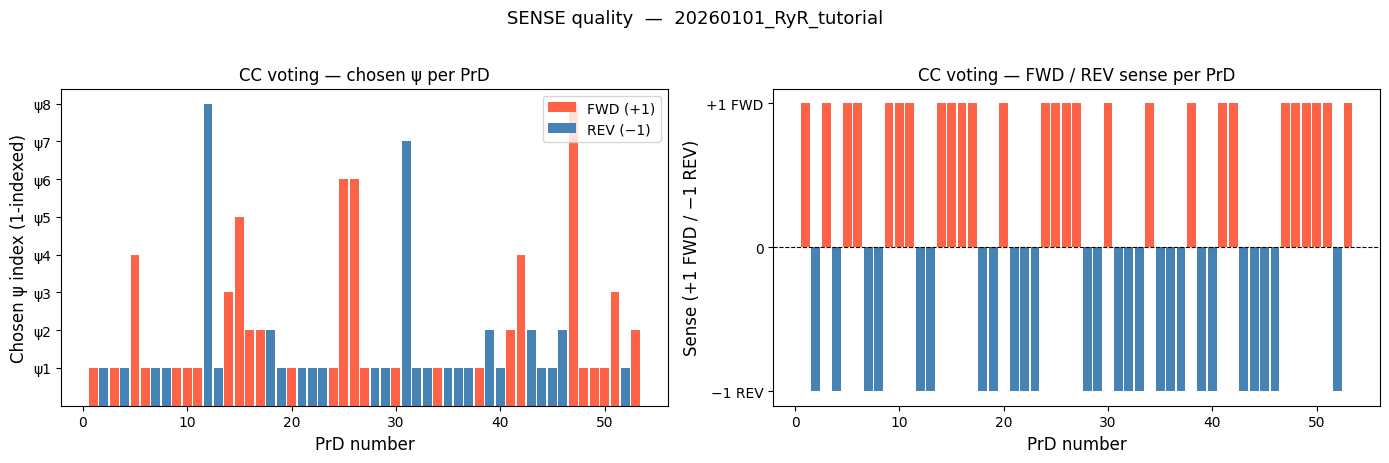

CC data loaded: 53 PrDs  |  ψ choices: {1: 35, 2: 8, 3: 2, 4: 2, 5: 1, 6: 2, 7: 1, 8: 2}


In [14]:
viz.show_cc_voting(interactive=INTERACTIVE)

### Optical-flow quiver per PrD × ψ

For each (PrD, ψ) pair, overlay the forward (`τ: 0→1`) and reverse (`τ: 1→0`) optical-flow vectors on the 2D class average. The chosen ψ (from CC voting) is marked with a ★.

> With `INTERACTIVE=True`, drive this with the PrD and ψ sliders. With `INTERACTIVE=False`, it renders PrD 1 / ψ 1 (override via `viz.show_optical_flow(default_prd=N, default_psi=K, interactive=INTERACTIVE)`).

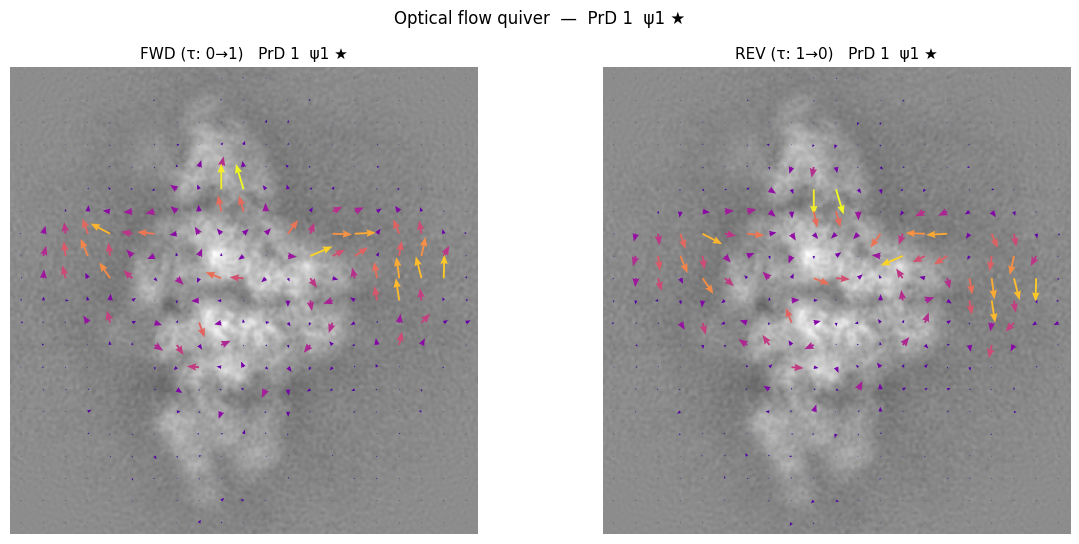

[static view — showing PrD 1, ψ1. Set INTERACTIVE=True for the PrD/ψ sliders.]


In [15]:
viz.show_optical_flow(interactive=INTERACTIVE)

### Trajectory free-energy landscape

Per-state histogram `hUn` (50 conformational bins along τ) and the corresponding free-energy curve  $\Delta G(\tau) = -\ln P(\tau)$ in units of $k_BT$, with the KDE of `tauAvg` overlaid for reference.

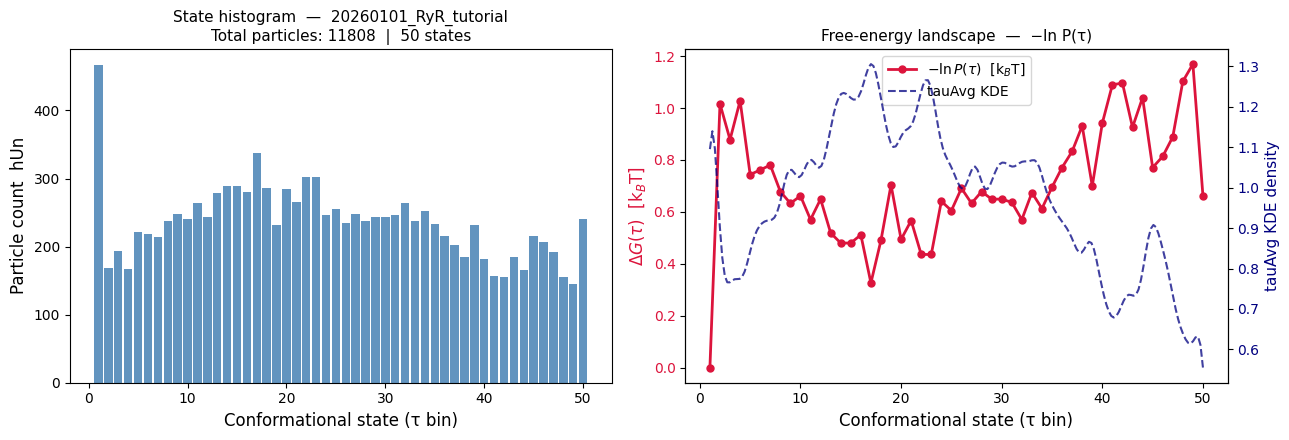

hUn: min=145  max=467  total=11808


In [16]:
viz.show_trajectory()